In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os
import json
import zipfile
import random
import shutil
import requests
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
PROJECT_DIR = Path("/content/drive/MyDrive/AI_Skin_Diagnosis")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

DOWNLOAD_DIR = PROJECT_DIR
OUTPUT_DIR = PROJECT_DIR / "SkinDisNet_Model"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXTRACT_DIR = Path("/content/SkinDisNet_Extracted")
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Model output folder:", OUTPUT_DIR)
print("Runtime extraction folder:", EXTRACT_DIR)

Project folder: /content/drive/MyDrive/AI_Skin_Diagnosis
Model output folder: /content/drive/MyDrive/AI_Skin_Diagnosis/SkinDisNet_Model
Runtime extraction folder: /content/SkinDisNet_Extracted


In [3]:
import requests

url = "https://data.mendeley.com/public-files/datasets/yj3md44hxg/files/2e67c136-67c5-41c0-ae7b-298d601c447d/file_downloaded"
output_path = "/content/drive/MyDrive/AI_Skin_Diagnosis/Skindisnet_dataset.zip"

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

print("Starting remote cloud transfer...")
with requests.get(url, headers=headers, stream=True) as response:
    response.raise_for_status()
    with open(output_path, 'wb') as file:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
print("Transfer complete! File saved to Google Drive.")

Starting remote cloud transfer...
Transfer complete! File saved to Google Drive.


In [7]:
zip_files = sorted(DOWNLOAD_DIR.glob("*.zip"))
if not zip_files:
    raise FileNotFoundError("No ZIP files found in /content/drive/MyDrive/AI_Skin_Diagnosis")

print("ZIP files to inspect/extract:")
for z in zip_files:
    print(" -", z)

# Clear old extraction only inside /content, not Google Drive.
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

for zip_path in zip_files:
    print("Extracting:", zip_path.name)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

print("Extraction complete.")

ZIP files to inspect/extract:
 - /content/drive/MyDrive/AI_Skin_Diagnosis/Skindisnet_dataset.zip
Extracting: Skindisnet_dataset.zip
Extraction complete.


In [8]:
print("Top-level extracted structure:")
for path in sorted(EXTRACT_DIR.rglob("*")):
    if path.is_dir():
        depth = len(path.relative_to(EXTRACT_DIR).parts)
        if depth <= 3:
            print("  " * depth + path.name)

Top-level extracted structure:
  Augmented
    Atopic Dermatitis (AD)
    Contact Dermatitis (CD)
    Eczema (EC)
    Scabies (SC)
    Seborrheic Dermatitis (SD)
    Tinea Corporis (TC)
  Preprocessed
    Atopic Dermatitis (AD)
    Contact Dermatitis (CD)
    Eczema (EC)
    Scabies (SC)
    Seborrheic Dermatitis (SD)
    Tinea Corporis (TC)


In [13]:
CLASS_NAMES = [
    "Atopic Dermatitis",
    "Contact Dermatitis",
    "Eczema",
    "Scabies",
    "Seborrheic Dermatitis",
    "Tinea Corporis",
]

CLASS_ALIASES = {
    "Atopic Dermatitis": ["atopic dermatitis", "atopic_dermatitis", "atopic-dermatitis", "ad"],
    "Contact Dermatitis": ["contact dermatitis", "contact_dermatitis", "contact-dermatitis", "cd"],
    "Eczema": ["eczema", "ec"],
    "Scabies": ["scabies", "sc"],
    "Seborrheic Dermatitis": ["seborrheic dermatitis", "seborrhoeic dermatitis", "seborrheic_dermatitis", "seborrheic-dermatitis", "sd"],
    "Tinea Corporis": ["tinea corporis", "tinea_corporis", "tinea-corporis", "tc", "ringworm"],
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
AUGMENTED_KEYWORDS = {"augmented", "augmentation", "augment", "aug"}
USE_AUGMENTED_FOR_TRAINING = True


def normalize_name(value):
    value = value.lower().strip()
    for ch in ["_", "-", ".", "(", ")", "[", "]", "{"]:
        value = value.replace(ch, " ")
    value = " ".join(value.split())
    return value


def image_count(folder):
    return sum(
        1
        for file_path in folder.rglob("*")
        if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS
    )


def has_images(folder):
    return image_count(folder) > 0


def is_augmented_path(folder):
    normalized_parts = [normalize_name(part) for part in folder.parts]
    joined = " ".join(normalized_parts)
    return any(keyword in joined for keyword in AUGMENTED_KEYWORDS)


def find_class_dirs(root_dir, require_augmented=None):
    root_dir = Path(root_dir)
    dirs_with_images = [p for p in root_dir.rglob("*") if p.is_dir() and has_images(p)]
    class_dirs = {}

    for class_name, aliases in CLASS_ALIASES.items():
        normalized_aliases = {normalize_name(alias) for alias in aliases}
        matches = []

        for folder in dirs_with_images:
            augmented = is_augmented_path(folder)
            if require_augmented is True and not augmented:
                continue
            if require_augmented is False and augmented:
                continue

            folder_name = normalize_name(folder.name)
            parent_text = normalize_name(" ".join(folder.parts[-6:]))

            exact = folder_name in normalized_aliases
            contained = any(alias in parent_text for alias in normalized_aliases if len(alias) > 2)

            if exact or contained:
                count = image_count(folder)
                # Prefer exact class folders, then larger folders.
                score = count + (100000 if exact else 0)
                matches.append((score, count, folder))

        if matches:
            matches.sort(reverse=True, key=lambda item: item[0])
            class_dirs[class_name] = matches[0][2]

    return class_dirs

original_class_dirs = find_class_dirs(EXTRACT_DIR, require_augmented=False)
augmented_class_dirs = find_class_dirs(EXTRACT_DIR, require_augmented=True)

if len(original_class_dirs) < len(CLASS_NAMES):
    print("Could not detect all original/preprocessed class folders. Falling back to any non-filtered class folders.")
    fallback_dirs = find_class_dirs(EXTRACT_DIR, require_augmented=None)
    for class_name in CLASS_NAMES:
        original_class_dirs.setdefault(class_name, fallback_dirs.get(class_name))

print("Original/preprocessed class folders:")
for class_name in CLASS_NAMES:
    print(class_name, "->", original_class_dirs.get(class_name))

print("\nAugmented class folders:")
for class_name in CLASS_NAMES:
    print(class_name, "->", augmented_class_dirs.get(class_name))

missing_original = [name for name in CLASS_NAMES if not original_class_dirs.get(name)]
if missing_original:
    raise FileNotFoundError(
        "Missing original/preprocessed class folders: " + ", ".join(missing_original) +
        "\nInspect the extracted folder output above and update CLASS_ALIASES or set original_class_dirs manually."
    )

missing_augmented = [name for name in CLASS_NAMES if not augmented_class_dirs.get(name)]
if missing_augmented:
    print("\nWarning: Missing augmented folders for:", missing_augmented)
    print("Training will continue with the available augmented folders only.")

Original/preprocessed class folders:
Atopic Dermatitis -> /content/SkinDisNet_Extracted/Preprocessed/Atopic Dermatitis (AD)
Contact Dermatitis -> /content/SkinDisNet_Extracted/Preprocessed/Contact Dermatitis (CD)
Eczema -> /content/SkinDisNet_Extracted/Preprocessed/Eczema (EC)
Scabies -> /content/SkinDisNet_Extracted/Preprocessed/Scabies (SC)
Seborrheic Dermatitis -> /content/SkinDisNet_Extracted/Preprocessed/Seborrheic Dermatitis (SD)
Tinea Corporis -> /content/SkinDisNet_Extracted/Preprocessed/Tinea Corporis (TC)

Augmented class folders:
Atopic Dermatitis -> /content/SkinDisNet_Extracted/Augmented/Atopic Dermatitis (AD)
Contact Dermatitis -> /content/SkinDisNet_Extracted/Augmented/Contact Dermatitis (CD)
Eczema -> /content/SkinDisNet_Extracted/Augmented/Eczema (EC)
Scabies -> /content/SkinDisNet_Extracted/Augmented/Scabies (SC)
Seborrheic Dermatitis -> /content/SkinDisNet_Extracted/Augmented/Seborrheic Dermatitis (SD)
Tinea Corporis -> /content/SkinDisNet_Extracted/Augmented/Tinea C

In [14]:
def build_dataframe_from_class_dirs(class_dirs, source_name):
    rows = []
    for class_name, folder in class_dirs.items():
        if folder is None:
            continue
        folder = Path(folder)
        for image_path in folder.rglob("*"):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append({
                    "image_path": str(image_path),
                    "label": class_name,
                    "source": source_name,
                })
    return pd.DataFrame(rows)

original_df = build_dataframe_from_class_dirs(original_class_dirs, "original")
augmented_df = build_dataframe_from_class_dirs(augmented_class_dirs, "augmented")

if original_df.empty:
    raise ValueError("No original/preprocessed images found after class folder detection.")

if USE_AUGMENTED_FOR_TRAINING and not augmented_df.empty:
    df = pd.concat([original_df, augmented_df], ignore_index=True)
else:
    df = original_df.copy()

df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Original/preprocessed images:", len(original_df))
print(original_df["label"].value_counts())
print("\nAugmented images:", len(augmented_df))
if not augmented_df.empty:
    print(augmented_df["label"].value_counts())
else:
    print("No augmented images detected.")

print("\nTotal indexed images:", len(df))
print(df.groupby(["source", "label"]).size())

df.to_csv(OUTPUT_DIR / "skindisnet_image_index.csv", index=False)
original_df.to_csv(OUTPUT_DIR / "skindisnet_original_image_index.csv", index=False)
augmented_df.to_csv(OUTPUT_DIR / "skindisnet_augmented_image_index.csv", index=False)
print("Saved image indexes to:", OUTPUT_DIR)

Original/preprocessed images: 1710
label
Contact Dermatitis       477
Eczema                   466
Scabies                  343
Tinea Corporis           275
Seborrheic Dermatitis     79
Atopic Dermatitis         70
Name: count, dtype: int64

Augmented images: 11970
label
Contact Dermatitis       3339
Eczema                   3262
Scabies                  2401
Tinea Corporis           1925
Seborrheic Dermatitis     553
Atopic Dermatitis         490
Name: count, dtype: int64

Total indexed images: 13680
source     label                
augmented  Atopic Dermatitis         490
           Contact Dermatitis       3339
           Eczema                   3262
           Scabies                  2401
           Seborrheic Dermatitis     553
           Tinea Corporis           1925
original   Atopic Dermatitis          70
           Contact Dermatitis        477
           Eczema                    466
           Scabies                   343
           Seborrheic Dermatitis      79
         

In [15]:
label_to_id = {name: idx for idx, name in enumerate(CLASS_NAMES)}
id_to_label = {idx: name for name, idx in label_to_id.items()}

original_df = original_df.copy()
augmented_df = augmented_df.copy()
original_df["label_id"] = original_df["label"].map(label_to_id)
augmented_df["label_id"] = augmented_df["label"].map(label_to_id) if not augmented_df.empty else []

base_train_df, temp_df = train_test_split(
    original_df,
    test_size=0.30,
    stratify=original_df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

if USE_AUGMENTED_FOR_TRAINING and not augmented_df.empty:
    train_df = pd.concat([base_train_df, augmented_df], ignore_index=True)
    train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    print("Using augmented images in TRAINING only.")
else:
    train_df = base_train_df.copy().reset_index(drop=True)
    print("Using original/preprocessed images only.")

val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Base original train images:", len(base_train_df))
print("Augmented train images:", len(augmented_df) if USE_AUGMENTED_FOR_TRAINING else 0)
print("Final train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nFinal train distribution:\n", train_df["label"].value_counts())
print("\nValidation distribution:\n", val_df["label"].value_counts())
print("\nTest distribution:\n", test_df["label"].value_counts())

train_df.to_csv(OUTPUT_DIR / "train_split.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_split.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_split.csv", index=False)

with open(OUTPUT_DIR / "labels.json", "w") as f:
    json.dump({str(k): v for k, v in id_to_label.items()}, f, indent=2)

Using augmented images in TRAINING only.
Base original train images: 1197
Augmented train images: 11970
Final train images: 13167
Validation images: 256
Test images: 257

Final train distribution:
 label
Contact Dermatitis       3673
Eczema                   3588
Scabies                  2641
Tinea Corporis           2118
Seborrheic Dermatitis     608
Atopic Dermatitis         539
Name: count, dtype: int64

Validation distribution:
 label
Contact Dermatitis       71
Eczema                   70
Scabies                  51
Tinea Corporis           41
Seborrheic Dermatitis    12
Atopic Dermatitis        11
Name: count, dtype: int64

Test distribution:
 label
Contact Dermatitis       72
Eczema                   70
Scabies                  52
Tinea Corporis           41
Seborrheic Dermatitis    12
Atopic Dermatitis        10
Name: count, dtype: int64


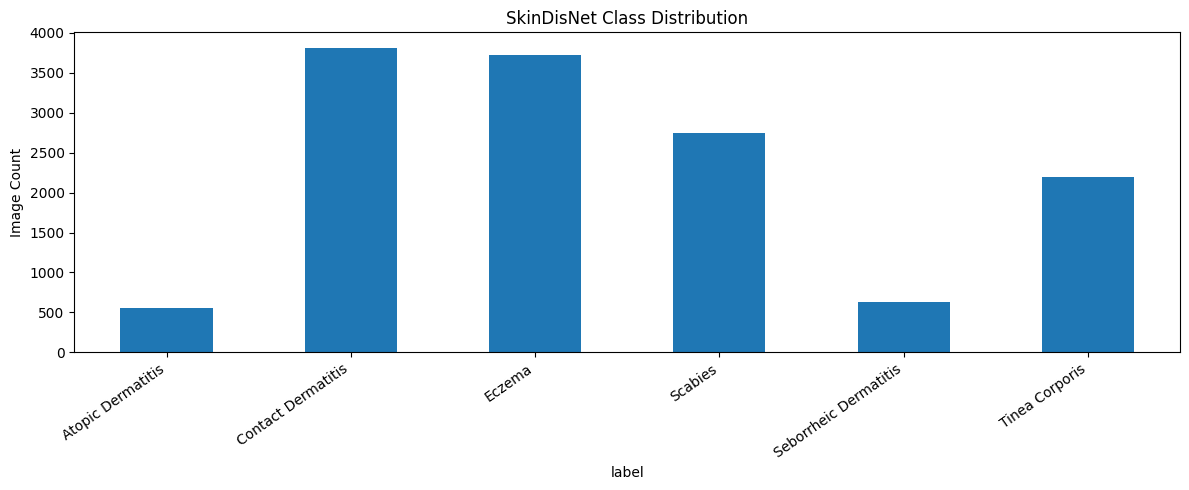

In [16]:
plt.figure(figsize=(12, 5))
df["label"].value_counts().loc[CLASS_NAMES].plot(kind="bar")
plt.title("SkinDisNet Class Distribution")
plt.ylabel("Image Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [17]:
IMG_SIZE = 300
BATCH_SIZE = 16
NUM_CLASSES = len(CLASS_NAMES)
AUTOTUNE = tf.data.AUTOTUNE


def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label


def make_dataset(dataframe, training=False):
    paths = dataframe["image_path"].values
    labels = dataframe["label_id"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (16, 300, 300, 3)
Label batch shape: (16, 6)


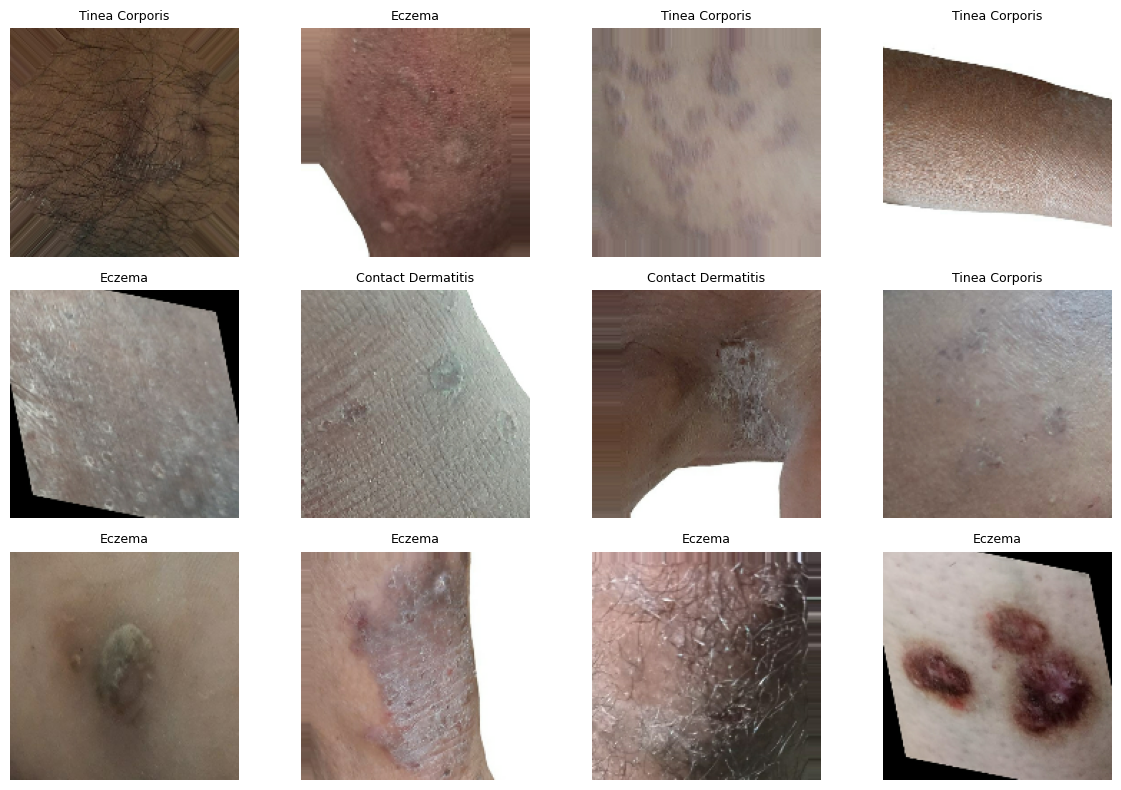

In [18]:
plt.figure(figsize=(12, 8))
sample_df = train_df.sample(n=min(12, len(train_df)), random_state=SEED).reset_index(drop=True)

for i, row in sample_df.iterrows():
    image = tf.io.read_file(row["image_path"])
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [160, 160]).numpy().astype("uint8")
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(row["label"], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetV2B3

try:
    AdamW = tf.keras.optimizers.AdamW
except AttributeError:
    AdamW = tf.keras.optimizers.Adam


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.15),
], name="data_augmentation")

base_model = EfficientNetV2B3(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_preprocessing=True,
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="skin_image")
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="disease_probability")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=AdamW(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy"),
    ],
)

model.summary()

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skin_image (InputLayer)         │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 10, 10, 1536)   │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disease_probability (Dense)     │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,331,780 (50.86 MB)

 Trainable params: 398,086 (1.52 MB)

 Non-trainable params: 12,933,694 (49.34 MB)

In [20]:
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["label_id"].values,
)

class_weights = {i: float(weight) for i, weight in enumerate(class_weights_values)}
print(class_weights)

{0: 4.071428571428571, 1: 0.5974680098012524, 2: 0.6116220735785953, 3: 0.8309352517985612, 4: 3.609375, 5: 1.0361189801699717}


In [21]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        mode="max",
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 1/25
823/823 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.3724 - loss: 2.2133 - top2_accuracy: 0.5953
Epoch 1: val_accuracy improved from None to 0.62109, saving model to /content/drive/MyDrive/AI_Skin_Diagnosis/SkinDisNet_Model/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI_Skin_Diagnosis/SkinDisNet_Model/best_model.keras
823/823 ━━━━━━━━━━━━━━━━━━━━ 141s 134ms/step - accuracy: 0.4138 - loss: 1.8642 - top2_accuracy: 0.6539 - val_accuracy: 0.6211 - val_loss: 1.1888 - val_top2_accuracy: 0.8164 - learning_rate: 0.0010
Epoch 2/25
823/823 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.4858 - loss: 1.3791 - top2_accuracy: 0.7278
Epoch 2: val_accuracy improved from 0.62109 to 0.66016, saving model to /content/drive/MyDrive/AI_Skin_Diagnosis/SkinDisNet_Model/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI_Skin_Diagnosis/SkinDisNet_Model/best_model.keras
823/823 ━━━━━━━━━━━━━━━━━━━━ 104s 126ms/step - accuracy: 0.4991 - lo

In [23]:
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.65)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=AdamW(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy"),
    ],
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 1/40
823/823 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.6213 - loss: 1.2524 - top2_accuracy: 0.8135
Epoch 1: val_accuracy did not improve from 0.89844
823/823 ━━━━━━━━━━━━━━━━━━━━ 228s 226ms/step - accuracy: 0.6440 - loss: 1.1820 - top2_accuracy: 0.8331 - val_accuracy: 0.8633 - val_loss: 0.7599 - val_top2_accuracy: 0.9492 - learning_rate: 1.0000e-05
Epoch 2/40
823/823 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.6913 - loss: 1.0469 - top2_accuracy: 0.8664
Epoch 2: val_accuracy did not improve from 0.89844
823/823 ━━━━━━━━━━━━━━━━━━━━ 194s 217ms/step - accuracy: 0.6970 - loss: 1.0340 - top2_accuracy: 0.8695 - val_accuracy: 0.8789 - val_loss: 0.7329 - val_top2_accuracy: 0.9609 - learning_rate: 1.0000e-05
Epoch 3/40
823/823 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.7145 - loss: 0.9712 - top2_accuracy: 0.8836
Epoch 3: val_accuracy did not improve from 0.89844
823/823 ━━━━━━━━━━━━━━━━━━━━ 201s 217ms/step - accuracy: 0.7176 - loss: 0.9692 - top2_accuracy: 0.8853 - val_

KeyboardInterrupt: 

In [24]:
best_model = tf.keras.models.load_model(OUTPUT_DIR / "best_model.keras")

test_metrics = best_model.evaluate(test_ds, verbose=1)
print(dict(zip(best_model.metrics_names, test_metrics)))

17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.9533 - loss: 0.5590 - top2_accuracy: 0.9883
{'loss': 0.5589852333068848, 'compile_metrics': 0.9533073902130127}


In [25]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(probs, axis=1))
    y_prob.extend(probs)

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
))

cm = confusion_matrix(y_true, y_pred)
print(cm)

                       precision    recall  f1-score   support

    Atopic Dermatitis     0.8333    1.0000    0.9091        10
   Contact Dermatitis     0.9857    0.9583    0.9718        72
               Eczema     0.9848    0.9286    0.9559        70
              Scabies     0.9444    0.9808    0.9623        52
Seborrheic Dermatitis     0.8571    1.0000    0.9231        12
       Tinea Corporis     0.9268    0.9268    0.9268        41

             accuracy                         0.9533       257
            macro avg     0.9221    0.9658    0.9415       257
         weighted avg     0.9558    0.9533    0.9537       257

[[10  0  0  0  0  0]
 [ 0 69  0  2  1  0]
 [ 0  1 65  1  1  2]
 [ 0  0  0 51  0  1]
 [ 0  0  0  0 12  0]
 [ 2  0  1  0  0 38]]


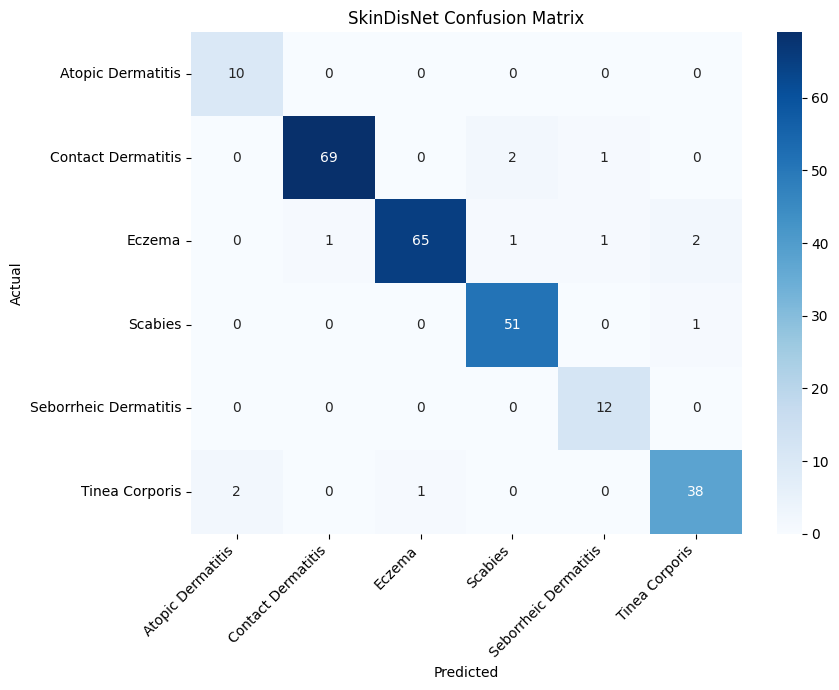

In [26]:
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SkinDisNet Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
final_model_path = OUTPUT_DIR / "skindisnet_efficientnetv2b3.keras"
best_model.save(final_model_path)
print("Saved Keras model:", final_model_path)

with open(OUTPUT_DIR / "labels.json", "w") as f:
    json.dump({str(k): v for k, v in id_to_label.items()}, f, indent=2)
print("Saved labels:", OUTPUT_DIR / "labels.json")

try:
    converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()

    tflite_path = OUTPUT_DIR / "skindisnet_efficientnetv2b3.tflite"
    with open(tflite_path, "wb") as f:
        f.write(tflite_model)
    print("Saved TFLite model:", tflite_path)
except Exception as exc:
    print("TFLite export skipped because of error:", exc)

Saved Keras model: /content/drive/MyDrive/AI_Skin_Diagnosis/SkinDisNet_Model/skindisnet_efficientnetv2b3.keras
Saved labels: /content/drive/MyDrive/AI_Skin_Diagnosis/SkinDisNet_Model/labels.json
Saved artifact at '/tmp/tmp3uhjm2ni'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='skin_image')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  139151324541008: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139151324540816: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139151324529104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139151324539856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139151324541392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139151324540432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139151324542544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1391513245400

In [28]:
def predict_image(image_path, model_path=OUTPUT_DIR / "best_model.keras"):
    model = tf.keras.models.load_model(model_path)

    image = tf.io.read_file(str(image_path))
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.expand_dims(image, axis=0)

    probs = model.predict(image, verbose=0)[0]
    top_indices = np.argsort(probs)[::-1][:3]

    return {
        "predicted_disease": id_to_label[int(top_indices[0])],
        "confidence": float(probs[top_indices[0]]),
        "top_3_predictions": [
            {
                "disease": id_to_label[int(idx)],
                "confidence": float(probs[idx]),
            }
            for idx in top_indices
        ],
    }

sample_image = test_df.iloc[0]["image_path"]
print("Testing image:", sample_image)
print(json.dumps(predict_image(sample_image), indent=2))

Testing image: /content/SkinDisNet_Extracted/Preprocessed/Contact Dermatitis (CD)/CD (165).jpg
{
  "predicted_disease": "Contact Dermatitis",
  "confidence": 0.9936029314994812,
  "top_3_predictions": [
    {
      "disease": "Contact Dermatitis",
      "confidence": 0.9936029314994812
    },
    {
      "disease": "Tinea Corporis",
      "confidence": 0.005855722352862358
    },
    {
      "disease": "Seborrheic Dermatitis",
      "confidence": 0.00024509677314199507
    }
  ]
}


In [29]:
MEDICINE_GUIDANCE = {
    "Atopic Dermatitis": {
        "category": "Moisturizer/emollient and doctor-approved anti-inflammatory cream",
        "examples": ["fragrance-free moisturizer", "emollient", "mild topical corticosteroid if doctor-approved"],
        "instruction": "Use moisturizer regularly and avoid irritants. Steroid or prescription creams should be used only after doctor approval.",
        "doctor_approval_required": True,
    },
    "Contact Dermatitis": {
        "category": "Trigger avoidance and anti-itch support",
        "examples": ["calamine lotion", "fragrance-free moisturizer", "hydrocortisone only if doctor-approved"],
        "instruction": "Avoid the suspected trigger. Seek doctor review if swelling, severe itching, or spreading occurs.",
        "doctor_approval_required": True,
    },
    "Eczema": {
        "category": "Moisturizer/emollient and doctor-approved medicated cream",
        "examples": ["emollient", "gentle cleanser", "topical corticosteroid if doctor-approved"],
        "instruction": "Keep the area moisturized and avoid harsh soaps. Medicated creams should be doctor-approved.",
        "doctor_approval_required": True,
    },
    "Scabies": {
        "category": "Doctor-approved scabicide treatment",
        "examples": ["permethrin 5% cream if prescribed", "ivermectin if prescribed"],
        "instruction": "Do not self-medicate. Scabies usually needs doctor-confirmed treatment and household contact management.",
        "doctor_approval_required": True,
    },
    "Seborrheic Dermatitis": {
        "category": "Antifungal shampoo or cream",
        "examples": ["ketoconazole shampoo", "ketoconazole cream", "anti-dandruff shampoo"],
        "instruction": "Use only as directed by a doctor, pharmacist, or product label. Consult doctor if recurrent or severe.",
        "doctor_approval_required": True,
    },
    "Tinea Corporis": {
        "category": "Topical antifungal",
        "examples": ["clotrimazole", "terbinafine", "miconazole", "ketoconazole"],
        "instruction": "Avoid steroid creams unless prescribed because they can worsen fungal infection. Consult doctor if widespread or not improving.",
        "doctor_approval_required": True,
    },
}


def risk_from_prediction(disease, confidence):
    if confidence < 0.60:
        return "High", True, "Low confidence. Doctor review required."
    if disease in ["Scabies", "Tinea Corporis"]:
        return "Moderate", True, "Doctor or pharmacist confirmation recommended before treatment."
    return "Low to Moderate", True, "Doctor approval recommended before final prescription."


def build_backend_result(prediction):
    disease = prediction["predicted_disease"]
    confidence = prediction["confidence"]
    risk_level, needs_doctor_review, doctor_reason = risk_from_prediction(disease, confidence)
    medicine = MEDICINE_GUIDANCE[disease]

    voice_text = (
        f"The detected condition may be {disease}. "
        f"The confidence score is {confidence:.2f}. "
        f"Risk level is {risk_level}. "
        f"Suggested guidance: {medicine['category']}. "
        f"Final medicine or prescription should be approved by a doctor."
    )

    return {
        "disease": disease,
        "confidence": confidence,
        "top_3_predictions": prediction["top_3_predictions"],
        "risk_level": risk_level,
        "needs_doctor_review": needs_doctor_review,
        "doctor_reason": doctor_reason,
        "medicine_guidance": medicine,
        "voice_text": voice_text,
    }

prediction = predict_image(sample_image)
backend_result = build_backend_result(prediction)
print(json.dumps(backend_result, indent=2))

{
  "disease": "Contact Dermatitis",
  "confidence": 0.9936029314994812,
  "top_3_predictions": [
    {
      "disease": "Contact Dermatitis",
      "confidence": 0.9936029314994812
    },
    {
      "disease": "Tinea Corporis",
      "confidence": 0.005855722352862358
    },
    {
      "disease": "Seborrheic Dermatitis",
      "confidence": 0.00024509677314199507
    }
  ],
  "risk_level": "Low to Moderate",
  "needs_doctor_review": true,
  "doctor_reason": "Doctor approval recommended before final prescription.",
  "medicine_guidance": {
    "category": "Trigger avoidance and anti-itch support",
    "examples": [
      "calamine lotion",
      "fragrance-free moisturizer",
      "hydrocortisone only if doctor-approved"
    ],
    "instruction": "Avoid the suspected trigger. Seek doctor review if swelling, severe itching, or spreading occurs.",
    "doctor_approval_required": true
  },
  "voice_text": "The detected condition may be Contact Dermatitis. The confidence score is 0.99. R